In [1]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from ortools.constraint_solver import routing_enums_pb2, pywrapcp
import time

# --- robust repo root ---
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'data').exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.route_parser import (
    build_distance_matrix,
    build_reverse_vrp_nodes,
    parse_solution,
    VEHICLE_CAPACITY_G,
    VEHICLE_SPEED_KMH,
    FIXED_COST_PER_ROUTE,
    VAR_COST_PER_KM,
    SERVICE_TIME_MIN,
    SOLVER_TIME_LIMIT_S,
    MAX_CUSTOMERS_PER_ZONE,
    NUM_VEHICLES,
)
from src.reverse_vrp import solve_reverse_cvrptw

DATA_DIR   = REPO_ROOT / 'data'
OUTPUT_DIR = REPO_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Setup complete. Repo root:', REPO_ROOT)

Setup complete. Repo root: Z:\PGDBA Content\Projects\Sem 2\SCA\SCA_DARK_STORES


In [3]:
# Load v3 — has return_prob and return_flag from classifier
master_df   = pd.read_parquet(DATA_DIR / "master_df_v3.parquet")
dark_stores = pd.read_csv(DATA_DIR / "dark_stores_final.csv")

# Filter to flagged return orders only
return_df = master_df[master_df["return_flag"] == 1].copy()

print(f"Total orders : {len(master_df):,}")
print(f"Return nodes : {len(return_df):,} ({len(return_df)/len(master_df)*100:.1f}%)")
print(f"Dark stores  : {len(dark_stores)}")

Total orders : 19,207
Return nodes : 602 (3.1%)
Dark stores  : 11


In [4]:
reverse_zones = build_reverse_vrp_nodes(
    return_df, dark_stores,
    max_per_zone=MAX_CUSTOMERS_PER_ZONE,
)

[build_reverse_vrp_nodes] 11 zones
  Zone  0: 50 pickups | weight = 156.8 kg
  Zone  1: 75 pickups | weight = 204.7 kg
  Zone  2: 59 pickups | weight = 97.9 kg
  Zone  3: 35 pickups | weight = 80.5 kg
  Zone  4: 45 pickups | weight = 166.7 kg
  Zone  5: 43 pickups | weight = 97.4 kg
  Zone  6: 46 pickups | weight = 100.0 kg
  Zone  7: 53 pickups | weight = 127.7 kg
  Zone  8: 46 pickups | weight = 76.0 kg
  Zone  9: 58 pickups | weight = 85.9 kg
  Zone 10: 72 pickups | weight = 178.2 kg


In [5]:
rows = []
for z in reverse_zones:
    for i, (coords, demand, tw, nid) in enumerate(zip(
            z["node_coords"], z["demands"], z["time_windows"], z["node_ids"])):
        rows.append({
            "zone_id":  z["zone_id"],
            "node_idx": i,
            "node_id":  nid,
            "lat":      round(float(coords[0]), 6),
            "lon":      round(float(coords[1]), 6),
            "demand_g": int(demand),
            "tw_open":  tw[0],
            "tw_close": tw[1],
            "is_depot": int(i == 0),
        })

reverse_vrp_nodes = pd.DataFrame(rows)
reverse_vrp_nodes.to_csv(DATA_DIR / "reverse_vrp_nodes.csv", index=False)
print(f"Saved: {DATA_DIR / 'reverse_vrp_nodes.csv'}  ({len(reverse_vrp_nodes)} rows)")
reverse_vrp_nodes.head(6)

Saved: Z:\PGDBA Content\Projects\Sem 2\SCA\SCA_DARK_STORES\data\reverse_vrp_nodes.csv  (593 rows)


,zone_id,node_idx,node_id,lat,lon,demand_g,tw_open,tw_close,is_depot
0,0,0,depot,-23.563536,-46.543798,0,0,1440,1
1,0,1,352,-23.530454,-46.556200,600,720,1080,0
2,0,2,444,-23.590649,-46.541716,22800,720,1080,0
3,0,3,661,-23.548841,-46.595182,1500,720,1080,0
4,0,4,838,-23.569725,-46.525425,750,720,1080,0
5,0,5,1021,-23.621427,-46.505098,11400,480,720,0


In [6]:
def solve_reverse_cvrptw(zone: dict, num_vehicles: int = 10) -> dict:
    n       = len(zone["node_coords"])
    demands = zone["demands"].tolist()
    tw      = zone["time_windows"]

    dist_matrix  = build_distance_matrix(zone["node_coords"])
    speed_m_per_min = VEHICLE_SPEED_KMH * 1000 / 60
    time_matrix  = np.rint(dist_matrix / speed_m_per_min).astype(int)

    manager = pywrapcp.RoutingIndexManager(n, num_vehicles, 0)
    routing = pywrapcp.RoutingModel(manager)

    def dist_cb(i, j):
        return int(dist_matrix[manager.IndexToNode(i)][manager.IndexToNode(j)])
    dist_cb_idx = routing.RegisterTransitCallback(dist_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(dist_cb_idx)

    def demand_cb(i):
        return int(demands[manager.IndexToNode(i)])
    dem_cb_idx = routing.RegisterUnaryTransitCallback(demand_cb)
    routing.AddDimensionWithVehicleCapacity(
        dem_cb_idx, 0,
        [VEHICLE_CAPACITY_G] * num_vehicles,
        True, "Capacity")

    def time_cb(i, j):
        node_i  = manager.IndexToNode(i)
        travel  = int(time_matrix[node_i][manager.IndexToNode(j)])
        service = SERVICE_TIME_MIN if node_i != 0 else 0
        return travel + service
    time_cb_idx = routing.RegisterTransitCallback(time_cb)
    routing.AddDimension(time_cb_idx, 60, 1440, False, "Time")
    time_dim = routing.GetDimensionOrDie("Time")
    for node_idx, (open_t, close_t) in enumerate(tw):
        time_dim.CumulVar(manager.NodeToIndex(node_idx)).SetRange(open_t, close_t)

    penalty = 100_000
    for node in range(1, n):
        routing.AddDisjunction([manager.NodeToIndex(node)], penalty)

    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)
    params.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH)
    params.time_limit.seconds = SOLVER_TIME_LIMIT_S

    assignment = routing.SolveWithParameters(params)

    if assignment is None:
        print(f"  Zone {zone['zone_id']}: NO SOLUTION FOUND")
        return {"zone_id": zone["zone_id"], "solved": False}

    routes_df, summary = parse_solution(
        manager, routing, assignment,
        zone["node_coords"], zone["node_ids"],
        distance_matrix=dist_matrix
    )
    routes_df["zone_id"] = zone["zone_id"]

    total_dist_km = summary["total_distance_km"]
    n_vehicles    = summary["n_vehicles_used"]
    routing_cost  = FIXED_COST_PER_ROUTE * n_vehicles + VAR_COST_PER_KM * total_dist_km

    print(f"  Zone {zone['zone_id']:2d}: {n_vehicles} vehicles | "
          f"{total_dist_km:.1f} km | R${routing_cost:.0f}")

    return {
        "zone_id":         zone["zone_id"],
        "solved":          True,
        "routes_df":       routes_df,
        "summary":         summary,
        "total_dist_km":   total_dist_km,
        "n_vehicles":      n_vehicles,
        "routing_cost_R$": routing_cost,
        "dist_matrix":     dist_matrix,
    }

print("Reverse solver function defined.")

Reverse solver function defined.


In [7]:
print("Running Reverse VRP (CVRPTW) — pickup routes...")
print(f"Time limit: {SOLVER_TIME_LIMIT_S}s per zone | "
      f"Vehicle capacity: {VEHICLE_CAPACITY_G/1000:.0f} kg\n")

reverse_results = {}
for z in reverse_zones:
    result = solve_reverse_cvrptw(z)
    reverse_results[z["zone_id"]] = result

n_solved = sum(r["solved"] for r in reverse_results.values())
print(f"\nCompleted: {n_solved}/{len(reverse_zones)} zones solved.")

Running Reverse VRP (CVRPTW) — pickup routes...
Time limit: 30s per zone | Vehicle capacity: 500 kg

  Zone  0: 2 vehicles | 78.1 km | R$217
  Zone  1: 1 vehicles | 79.9 km | R$170
  Zone  2: 2 vehicles | 96.6 km | R$245
  Zone  3: 1 vehicles | 57.8 km | R$137
  Zone  4: 2 vehicles | 81.8 km | R$223
  Zone  5: 2 vehicles | 88.3 km | R$232
  Zone  6: 2 vehicles | 80.9 km | R$221
  Zone  7: 3 vehicles | 69.8 km | R$255
  Zone  8: 3 vehicles | 95.4 km | R$293
  Zone  9: 2 vehicles | 84.4 km | R$227
  Zone 10: 2 vehicles | 86.5 km | R$230

Completed: 11/11 zones solved.


In [8]:
all_route_dfs = [r["routes_df"] for r in reverse_results.values()
                 if r["solved"] and "routes_df" in r]
reverse_routes_df = pd.concat(all_route_dfs, ignore_index=True)
reverse_routes_df.to_csv(OUTPUT_DIR / "reverse_routes.csv", index=False)

json_out = []
for zid, r in reverse_results.items():
    if not r["solved"]: continue
    json_out.append({
        "zone_id":         zid,
        "n_vehicles":      r["n_vehicles"],
        "total_dist_km":   r["total_dist_km"],
        "routing_cost_R$": r["routing_cost_R$"],
        "routes":          r["routes_df"].to_dict(orient="records"),
    })
with open(OUTPUT_DIR / "reverse_routes.json", "w") as f:
    json.dump(json_out, f, indent=2)

kpi_rows = []
for zid, r in reverse_results.items():
    if not r["solved"]: continue
    kpi_rows.append({
        "zone_id":         zid,
        "n_pickups":       next(z["n_pickups"] for z in reverse_zones if z["zone_id"] == zid),
        "n_vehicles_used": r["n_vehicles"],
        "total_dist_km":   round(r["total_dist_km"], 2),
        "routing_cost_R$": round(r["routing_cost_R$"], 2),
        "max_route_km":    r["summary"]["max_route_km"],
        "min_route_km":    r["summary"]["min_route_km"],
    })
kpi_df = pd.DataFrame(kpi_rows)
kpi_df.to_csv(OUTPUT_DIR / "reverse_kpi_summary.csv", index=False)

print("Saved:")
print(f"  {OUTPUT_DIR / 'reverse_routes.csv'}")
print(f"  {OUTPUT_DIR / 'reverse_routes.json'}")
print(f"  {OUTPUT_DIR / 'reverse_kpi_summary.csv'}")
print()
print(kpi_df.to_string(index=False))

Saved:
  Z:\PGDBA Content\Projects\Sem 2\SCA\SCA_DARK_STORES\outputs\reverse_routes.csv
  Z:\PGDBA Content\Projects\Sem 2\SCA\SCA_DARK_STORES\outputs\reverse_routes.json
  Z:\PGDBA Content\Projects\Sem 2\SCA\SCA_DARK_STORES\outputs\reverse_kpi_summary.csv

 zone_id  n_pickups  n_vehicles_used  total_dist_km  routing_cost_R$  max_route_km  min_route_km
       0         50                2          78.10           217.15         43.16         34.94
       1         75                1          79.89           169.84         79.89         79.89
       2         59                2          96.56           244.84         59.83         36.73
       3         35                1          57.77           136.66         57.77         57.77
       4         45                2          81.84           222.76         45.77         36.08
       5         43                2          88.30           232.45         46.74         41.56
       6         46                2          80.94           22

In [9]:
fwd_kpi = pd.read_csv(OUTPUT_DIR / "forward_kpi_summary.csv")
rev_kpi = kpi_df.copy()

merged = fwd_kpi.merge(rev_kpi, on="zone_id", suffixes=("_fwd", "_rev"))

print("=" * 60)
print("FORWARD vs REVERSE VRP — ZONE-LEVEL COMPARISON")
print("=" * 60)
print(merged[["zone_id",
              "n_customers", "n_pickups",
              "total_dist_km_fwd", "total_dist_km_rev",
              "routing_cost_R$_fwd", "routing_cost_R$_rev"]].to_string(index=False))

print("\n" + "=" * 60)
print("TOTALS")
print("=" * 60)
print(f"  Forward  — dist: {fwd_kpi['total_dist_km'].sum():.1f} km | "
      f"cost: R${fwd_kpi['routing_cost_R$'].sum():.0f} | "
      f"vehicles: {fwd_kpi['n_vehicles_used'].sum()}")
print(f"  Reverse  — dist: {rev_kpi['total_dist_km'].sum():.1f} km | "
      f"cost: R${rev_kpi['routing_cost_R$'].sum():.0f} | "
      f"vehicles: {rev_kpi['n_vehicles_used'].sum()}")
total_cost = fwd_kpi['routing_cost_R$'].sum() + rev_kpi['routing_cost_R$'].sum()
print(f"\n  Combined total cost: R${total_cost:.0f}")
print("=" * 60)

FORWARD vs REVERSE VRP — ZONE-LEVEL COMPARISON
 zone_id  n_customers  n_pickups  total_dist_km_fwd  total_dist_km_rev  routing_cost_R$_fwd  routing_cost_R$_rev
       0           75         50              95.25              78.10               242.88               217.15
       1           75         75              81.54              79.89               222.31               169.84
       2           75         59             109.69              96.56               214.54               244.84
       3           75         35              99.37              57.77               199.06               136.66
       4           75         45              88.57              81.84               282.86               222.76
       5           75         43             112.89              88.30               219.34               232.45
       6           75         46              97.33              80.94               246.00               221.41
       7           75         53             103.

## Solver Tuning

Test 3 strategies on a subset of zones using reverse_zones already in memory. Update FIRST_SOLUTION_STRATEGY, LOCAL_SEARCH_METAHEURISTIC, and STRATEGY_LABEL in `src/reverse_vrp.py` with the winner.

In [15]:
STRATEGIES = [
    (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC,
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH,
        "PATH_CHEAPEST_ARC + GUIDED_LOCAL_SEARCH",
    ),
    (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC,
        routing_enums_pb2.LocalSearchMetaheuristic.SIMULATED_ANNEALING,
        "PATH_CHEAPEST_ARC + SIMULATED_ANNEALING",
    ),
    (
        routing_enums_pb2.FirstSolutionStrategy.AUTOMATIC,
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH,
        "AUTOMATIC + GUIDED_LOCAL_SEARCH",
    ),
    (
        routing_enums_pb2.FirstSolutionStrategy.SAVINGS,
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH,
        "SAVINGS + GUIDED_LOCAL_SEARCH",
    ),
    (
        routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION,
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH,
        "PARALLEL_CHEAPEST_INSERTION + GUIDED_LOCAL_SEARCH",
    ),
    (
        routing_enums_pb2.FirstSolutionStrategy.CHRISTOFIDES,
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH,
        "CHRISTOFIDES + GUIDED_LOCAL_SEARCH",
    ),
]

TUNE_ZONE_IDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # all 11 zones
TUNE_TIME_LIMIT_S = 120  # give each solve 2 minutes

print(f'Tuning on zones: {TUNE_ZONE_IDS}')
print(f'Strategies     : {len(STRATEGIES)}')
print(f'Total solves   : {len(TUNE_ZONE_IDS) * len(STRATEGIES)} (~{len(TUNE_ZONE_IDS) * len(STRATEGIES) * TUNE_TIME_LIMIT_S / 60:.0f} min max)')

Tuning on zones: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Strategies     : 6
Total solves   : 66 (~132 min max)


In [16]:
tuning_rows = []

for zone in [z for z in reverse_zones if z['zone_id'] in TUNE_ZONE_IDS]:
    print(f"\nZone {zone['zone_id']} ({zone['n_pickups']} pickups)")
    n       = len(zone['node_coords'])
    demands = zone['demands'].tolist()
    tw      = zone['time_windows']
    dist_m  = build_distance_matrix(zone['node_coords'])
    time_m  = np.rint(dist_m / (VEHICLE_SPEED_KMH * 1000 / 60)).astype(int)

    for fss, lsm, label in STRATEGIES:
        manager = pywrapcp.RoutingIndexManager(n, NUM_VEHICLES, 0)
        routing = pywrapcp.RoutingModel(manager)

        def dist_cb(i, j, _d=dist_m, _m=manager):
            return int(_d[_m.IndexToNode(i)][_m.IndexToNode(j)])
        dci = routing.RegisterTransitCallback(dist_cb)
        routing.SetArcCostEvaluatorOfAllVehicles(dci)

        def demand_cb(i, _dem=demands, _m=manager):
            return int(_dem[_m.IndexToNode(i)])
        dei = routing.RegisterUnaryTransitCallback(demand_cb)
        routing.AddDimensionWithVehicleCapacity(
            dei, 0, [VEHICLE_CAPACITY_G] * NUM_VEHICLES, True, 'Capacity'
        )

        def time_cb(i, j, _t=time_m, _m=manager):
            ni = _m.IndexToNode(i)
            return int(_t[ni][_m.IndexToNode(j)]) + (SERVICE_TIME_MIN if ni != 0 else 0)
        tci = routing.RegisterTransitCallback(time_cb)
        routing.AddDimension(tci, 60, 1440, False, 'Time')
        time_dim = routing.GetDimensionOrDie('Time')
        for ni, (o, c) in enumerate(tw):
            time_dim.CumulVar(manager.NodeToIndex(ni)).SetRange(o, c)
        for nd in range(1, n):
            routing.AddDisjunction([manager.NodeToIndex(nd)], 100_000)

        params = pywrapcp.DefaultRoutingSearchParameters()
        params.first_solution_strategy    = fss
        params.local_search_metaheuristic = lsm
        params.time_limit.seconds         = TUNE_TIME_LIMIT_S

        t0         = time.time()
        assignment = routing.SolveWithParameters(params)
        elapsed    = round(time.time() - t0, 2)

        if assignment:
            _, summary = parse_solution(
                manager, routing, assignment,
                zone['node_coords'], zone['node_ids'], dist_m
            )
            dist_km = summary['total_distance_km']
            n_veh   = summary['n_vehicles_used']
            cost    = FIXED_COST_PER_ROUTE * n_veh + VAR_COST_PER_KM * dist_km
            print(f'  {label:<52s} → {dist_km:.1f} km | R${cost:.0f} | {elapsed}s')
            tuning_rows.append({
                'zone_id': zone['zone_id'], 'n_pickups': zone['n_pickups'],
                'strategy': label, 'solved': True, 'solve_time_s': elapsed,
                'total_dist_km': dist_km, 'n_vehicles': n_veh, 'routing_cost_R$': cost,
            })
        else:
            print(f'  {label:<52s} → NO SOLUTION ({elapsed}s)')
            tuning_rows.append({
                'zone_id': zone['zone_id'], 'n_pickups': zone['n_pickups'],
                'strategy': label, 'solved': False, 'solve_time_s': elapsed,
                'total_dist_km': None, 'n_vehicles': None, 'routing_cost_R$': None,
            })



Zone 0 (50 pickups)
  PATH_CHEAPEST_ARC + GUIDED_LOCAL_SEARCH              → 76.4 km | R$265 | 120.0s
  PATH_CHEAPEST_ARC + SIMULATED_ANNEALING              → 88.2 km | R$182 | 120.0s
  AUTOMATIC + GUIDED_LOCAL_SEARCH                      → 76.4 km | R$265 | 120.0s
  SAVINGS + GUIDED_LOCAL_SEARCH                        → 76.4 km | R$265 | 120.0s
  PARALLEL_CHEAPEST_INSERTION + GUIDED_LOCAL_SEARCH    → 76.4 km | R$265 | 120.0s
  CHRISTOFIDES + GUIDED_LOCAL_SEARCH                   → 76.4 km | R$265 | 120.0s

Zone 1 (75 pickups)
  PATH_CHEAPEST_ARC + GUIDED_LOCAL_SEARCH              → 79.8 km | R$220 | 120.0s
  PATH_CHEAPEST_ARC + SIMULATED_ANNEALING              → 81.8 km | R$223 | 120.0s
  AUTOMATIC + GUIDED_LOCAL_SEARCH                      → 79.8 km | R$220 | 120.0s
  SAVINGS + GUIDED_LOCAL_SEARCH                        → 79.9 km | R$170 | 120.0s
  PARALLEL_CHEAPEST_INSERTION + GUIDED_LOCAL_SEARCH    → 79.8 km | R$220 | 120.0s
  CHRISTOFIDES + GUIDED_LOCAL_SEARCH                   →

In [17]:
tuning_df = pd.DataFrame(tuning_rows)
tuning_df.to_csv(OUTPUT_DIR / 'solver_tuning_results.csv', index=False)
print('Saved solver_tuning_results.csv')
print()
tuning_df


Saved solver_tuning_results.csv



,zone_id,n_pickups,strategy,solved,solve_time_s,total_dist_km,n_vehicles,routing_cost_R$
0,0,50,PATH_CHEAPEST_ARC + GUIDED_LOCAL_SEARCH,True,120.0,76.43,3,264.645
1,0,50,PATH_CHEAPEST_ARC + SIMULATED_ANNEALING,True,120.0,88.24,1,182.360
2,0,50,AUTOMATIC + GUIDED_LOCAL_SEARCH,True,120.0,76.43,3,264.645
3,0,50,SAVINGS + GUIDED_LOCAL_SEARCH,True,120.0,76.43,3,264.645
4,0,50,PARALLEL_CHEAPEST_INSERTION + GUIDED_LOCAL_SEARCH,True,120.0,76.43,3,264.645
...,...,...,...,...,...,...,...,...
61,10,72,PATH_CHEAPEST_ARC + SIMULATED_ANNEALING,True,120.0,86.85,1,180.275
62,10,72,AUTOMATIC + GUIDED_LOCAL_SEARCH,True,120.0,86.47,2,229.705
63,10,72,SAVINGS + GUIDED_LOCAL_SEARCH,True,120.0,86.47,2,229.705
64,10,72,PARALLEL_CHEAPEST_INSERTION + GUIDED_LOCAL_SEARCH,True,120.0,86.47,2,229.705


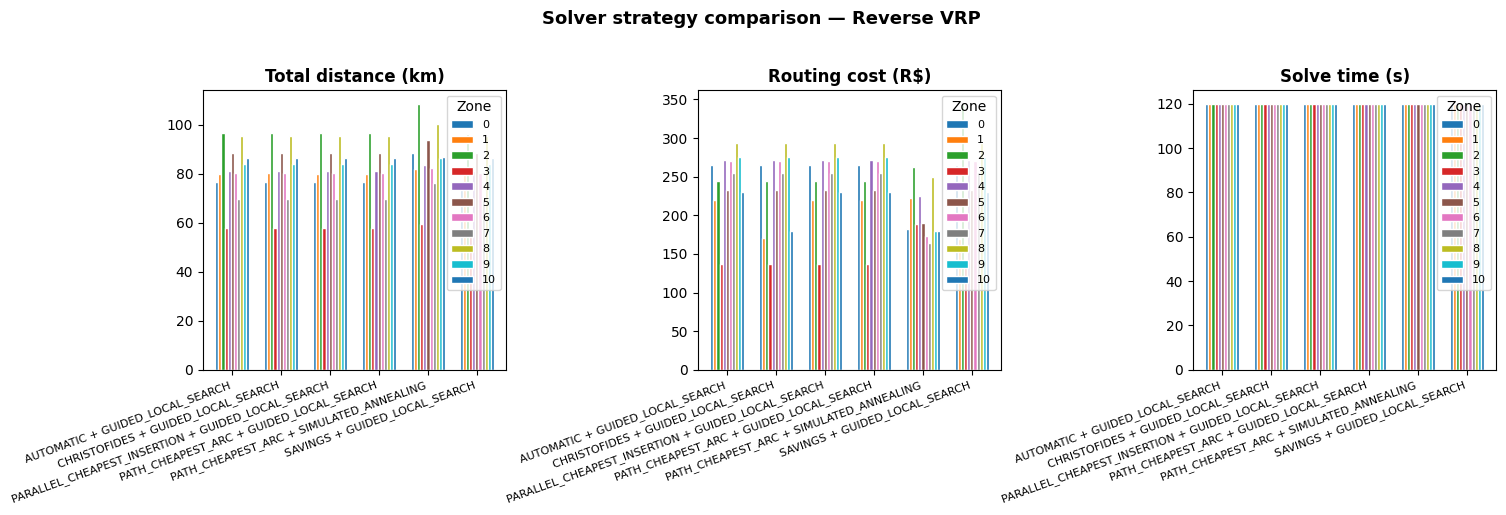

Saved solver_tuning_comparison.png


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['total_dist_km', 'routing_cost_R$', 'solve_time_s']
titles  = ['Total distance (km)', 'Routing cost (R$)', 'Solve time (s)']

for ax, metric, title in zip(axes, metrics, titles):
    pivot = tuning_df[tuning_df['solved']].pivot(
        index='strategy', columns='zone_id', values=metric
    )
    pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
    ax.legend(title='Zone', fontsize=8)

plt.suptitle('Solver strategy comparison — Reverse VRP',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'solver_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved solver_tuning_comparison.png')

In [19]:
# Best strategy summary
summary = (
    tuning_df[tuning_df['solved']]
    .groupby('strategy')[['total_dist_km', 'routing_cost_R$', 'solve_time_s']]
    .mean().round(2)
    .sort_values('routing_cost_R$')
)
print('Average across tuned zones (lower cost = better):')
print(summary.to_string())
print()
best = summary.index[0]
print(f'Winner: {best}')
print()
print('Update src/reverse_vrp.py:')
print('  FIRST_SOLUTION_STRATEGY    = ...')
print('  LOCAL_SEARCH_METAHEURISTIC = ...')
print(f'  STRATEGY_LABEL             = "{best}"')

Average across tuned zones (lower cost = better):
                                                   total_dist_km  routing_cost_R$  solve_time_s
strategy                                                                                       
PATH_CHEAPEST_ARC + SIMULATED_ANNEALING                    86.06           201.81         120.0
CHRISTOFIDES + GUIDED_LOCAL_SEARCH                         81.46           235.83         120.0
PARALLEL_CHEAPEST_INSERTION + GUIDED_LOCAL_SEARCH          81.43           244.88         120.0
AUTOMATIC + GUIDED_LOCAL_SEARCH                            81.43           244.88         120.0
PATH_CHEAPEST_ARC + GUIDED_LOCAL_SEARCH                    81.43           244.88         120.0
SAVINGS + GUIDED_LOCAL_SEARCH                              81.42           249.40         120.0

Winner: PATH_CHEAPEST_ARC + SIMULATED_ANNEALING

Update src/reverse_vrp.py:
  FIRST_SOLUTION_STRATEGY    = ...
  LOCAL_SEARCH_METAHEURISTIC = ...
  STRATEGY_LABEL             = "PAT